In [1]:
from IPython.display import display, HTML

display(HTML('''
<div style="display: flex; align-items: center; justify-content: center;
            gap: 0; padding: 20px 0; background: white;">
    <div style="padding: 0 30px;">
        <img src="assets/eneos_logo.png" alt="ENEOS"
             style="height: 55px; max-width: 180px; object-fit: contain;">
    </div>
    <div style="width: 1px; height: 50px; background: #999;"></div>
    <div style="padding: 0 30px;">
        <img src="assets/matlantis_logo.png" alt="Matlantis"
             style="height: 35px; max-width: 200px; object-fit: contain;">
    </div>
    <div style="width: 1px; height: 50px; background: #999;"></div>
    <div style="padding: 0 30px;">
        <img src="assets/nvidia-logo-vert-rgb-blk-no-reg-for-screen.png" alt="NVIDIA"
             style="height: 60px; max-width: 180px; object-fit: contain;">
    </div>
</div>
'''))

# Batched Slab Relaxation for OER Catalyst Screening with NVIDIA ALCHEMI

**Screening oxide catalyst surfaces for oxygen-evolution activity using the ALCHEMI BGR NIM**

## Why This Matters

### The hydrogen opportunity

Hydrogen is a clean-burning fuel that produces only water when consumed. If it can be manufactured cheaply from water and renewable electricity, it becomes a cornerstone of the energy transition — powering heavy transport, steel-making, and chemical synthesis without carbon emissions.

The simplest route is **water electrolysis**: pass an electric current through water and it splits into hydrogen gas (H$_2$) at the cathode and oxygen gas (O$_2$) at the anode. In principle, the minimum voltage required is just **1.23 V**. In practice, today's electrolysers need substantially more — the extra voltage, called the **overpotential**, is wasted as heat. Most of that penalty comes from the oxygen side of the reaction, known as the **Oxygen Evolution Reaction (OER)**.

### The catalyst bottleneck

A good OER catalyst lowers the overpotential, making the process more energy-efficient. The best-performing catalyst for acidic electrolysers is **iridium oxide (IrO$_2$)**, but iridium is one of the rarest elements on Earth. The **U.S. Geological Survey lists it among its 60 critical minerals** — materials vital to the economy whose supply chains are vulnerable to disruption. Global iridium production is only about 7–8 tonnes per year. Scaling electrolysers to meet climate targets could strain this supply, so there is urgent industrial interest in finding cheaper, more abundant alternatives.

### Computational screening

Testing catalyst candidates in the laboratory is expensive and slow. **Computational screening** lets researchers evaluate hundreds of candidate structures on a computer *before* committing to experiments. By simulating how oxygen-containing molecules bind to a catalyst surface, we can rank materials by their predicted activity and focus laboratory work on the most promising candidates.

This playbook demonstrates that workflow using the **NVIDIA ALCHEMI BGR (Batch Geometry Relaxation) NIM**. We screen three oxide catalyst surfaces — **IrO$_2$**, **RuO$_2$**, and **TiO$_2$** — for their interaction with key OER intermediates. The workflow is motivated by the collaboration between **ENEOS**, **Matlantis**, and **NVIDIA** on GPU-accelerated atomistic simulation for industrial catalyst discovery.

### What to expect

Throughout this notebook we use **3-D structure visualisations** (rendered with OVITO) and **before-and-after relaxation comparisons** to make the results intuitive — even if you are not a computational chemist. Each section includes discussion prompts about what can and cannot be concluded from the results.

> **Scope note:** This notebook performs structural screening — a rapid first pass that identifies plausible binding geometries and relative trends. It is not a full thermodynamic analysis and does not replace calculations with explicit solvent, entropy corrections, or electrochemical boundary conditions. Think of it as the first funnel in a multi-stage discovery pipeline.

## What You Will Learn

| Stage | Skill |
|-------|-------|
| **Build** | Construct oxide catalyst bulk crystals and (110) surface slabs with pymatgen |
| **Place** | Position OER adsorbates (H$_2$O, OH, O, OOH) at catalytically active surface sites |
| **Relax** | Batch-relax 30+ slab-adsorbate structures via the ALCHEMI BGR NIM |
| **Classify** | Assess relaxation quality (converged, migrated, dissociated, desorbed) |
| **Analyse** | Compute adsorption energies, rank materials, and compare to literature |
| **Visualise** | Render 3-D structures, displacement maps, and a 3-D screening scatter plot |

### Prerequisites

| Requirement | Version |
|-------------|---------|
| Python | $\geq$ 3.11 |
| conda env | `alchemi-playbook` |
| BGR NIM | running on `localhost` (or set `FAST_DEMO = True` for cached mode) |

---
## 1. Environment Setup

In [2]:
import importlib.metadata

print("Package versions:")
for pkg in ["ase", "pymatgen", "pydantic", "requests", "matplotlib", "numpy", "pandas"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")

try:
    import ovito  # noqa: F401

    print(f"  ovito: {importlib.metadata.version('ovito')}")
    OVITO_AVAILABLE = True
except ImportError:
    print("  ovito: not available (structure renders will be skipped)")
    OVITO_AVAILABLE = False

Package versions:
  ase: 3.27.0
  pymatgen: 2025.10.7
  pydantic: 2.12.5
  requests: 2.32.5
  matplotlib: 3.10.8
  numpy: 2.4.2
  pandas: 3.0.1
  ovito: 3.15.0


In [3]:
# ─── Control Panel ─────────────────────────────────────────────────────────────
# Flip FAST_DEMO to True to use cached responses instead of live endpoint calls.
FAST_DEMO = False

# BGR NIM endpoint (adjust port if your deployment differs)
BGR_PORT = 8000
BGR_SERVER = f"http://localhost:{BGR_PORT}"

# Surface parameters
MILLER_INDEX = (1, 1, 0)
SUPERCELL = (6, 6, 1)
MIN_SLAB_SIZE = 10.0  # Angstrom (~4-5 layers for rutile 110)
MIN_VACUUM = 15.0  # Angstrom vacuum gap above slab
BOTTOM_FROZEN = 0.5  # Freeze bottom 50% of slab atoms

# Rutile oxide lattice parameters: (metal, a, c, u_oxygen)
# a, c = tetragonal cell edges (Angstrom); u = oxygen Wyckoff 4f coordinate
RUTILE_PARAMS = {
    "IrO2": ("Ir", 4.499, 3.154, 0.3065),
    "RuO2": ("Ru", 4.492, 3.107, 0.3058),
    "TiO2": ("Ti", 4.594, 2.958, 0.3048),
}

METAL_Z = {"Ir": 77, "Ru": 44, "Ti": 22}

# Adsorbates and placement configurations
ADSORBATES = ["H2O", "OH", "O", "OOH"]
SITES = ["cus", "bridge"]

# Tilt angles in degrees (0 = upright, 30 = tilted toward bridging oxygen)
ORIENTATIONS = {
    "H2O": [0.0, 30.0],
    "OH": [0.0, 30.0],
    "O": [0.0],  # Single atom — tilt is meaningless
    "OOH": [0.0, 30.0],
}

# Adsorbate placement height above surface site (Angstrom).
# ~2.0 A approximates the equilibrium M-O bond length for these oxides.
ADSORBATE_HEIGHT = 3.5

# Which material to relax live (rest loaded from cache)
LIVE_MATERIAL = "IrO2"

# Directories
CACHE_DIR = "cached_responses/oer-catalyst-screening"
OUTPUT_DIR = "outputs"

# Vacuum box size for gas-phase reference molecules (Angstrom)
GAS_BOX_SIZE = 30.0

In [4]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.patches as mpatches
import ase
import ase.data

from helpers import (
    # BGR API
    check_endpoint,
    run_bgr_or_load_cache,
    async_run_bgr_or_load_cache,
    ase_to_atomic_data,
    atomic_data_to_ase,
    # Surface utilities
    build_rutile_bulk,
    build_slab,
    make_active_mask,
    find_cus_sites,
    find_bridge_site,
    find_central_site,
    build_adsorbate,
    place_adsorbate,
    classify_relaxation,
    compute_adsorption_energy,
    compute_surface_displacement,
    # Visualisation
    render_structure_ovito,
    create_interactive_view,
    display_inline,
    structure_summary_table,
    # Constants
    EV_PER_OER_STEP,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

warnings.filterwarnings("ignore", category=DeprecationWarning)
print("Helpers loaded. Ready to go.")

Helpers loaded. Ready to go.


---
## 2. Endpoint Connectivity

In [5]:
bgr_live = check_endpoint(BGR_SERVER) if not FAST_DEMO else False
status = "LIVE" if bgr_live else "offline (using cached responses)"
print(f"BGR NIM at {BGR_SERVER}: {status}")

BGR NIM at http://localhost:8000: LIVE


In [6]:
from IPython.display import JSON

# Quick API schema check: relax a trivial H2 molecule in a vacuum box
h2 = ase.Atoms("H2", positions=[[0, 0, 0], [0, 0, 0.74]])
h2.set_cell([10, 10, 10])
h2.set_pbc([True, True, True])
h2.center()

h2_ad = ase_to_atomic_data(h2, _id="h2_hello")
print("=== BGR REQUEST ===")
display(JSON(h2_ad.model_dump(), expanded=False, root="request"))

h2_reply = run_bgr_or_load_cache(
    [h2_ad], BGR_SERVER, CACHE_DIR, "h2_hello_world", bgr_live, timeout=60
)
print(f"\nResponse status: {h2_reply.status}")
print("=== BGR RESPONSE ===")
display(JSON(h2_reply.atoms[0].model_dump(), expanded=False, root="response"))

=== BGR REQUEST ===


<IPython.core.display.JSON object>

  Loading cached response: h2_hello_world

Response status: Success
=== BGR RESPONSE ===


<IPython.core.display.JSON object>

---
## 3. The Oxygen Evolution Reaction

### OER mechanism

At the anode of a water electrolyser, water is oxidised to molecular oxygen through four sequential proton-coupled electron transfer (PCET) steps on a catalytic surface (denoted $*$):

$$
\begin{aligned}
* + \text{H}_2\text{O} &\rightarrow \text{OH}^* + \text{H}^+ + e^- && (\Delta G_1) \\
\text{OH}^* &\rightarrow \text{O}^* + \text{H}^+ + e^- && (\Delta G_2) \\
\text{O}^* + \text{H}_2\text{O} &\rightarrow \text{OOH}^* + \text{H}^+ + e^- && (\Delta G_3) \\
\text{OOH}^* &\rightarrow * + \text{O}_2 + \text{H}^+ + e^- && (\Delta G_4)
\end{aligned}
$$

An **ideal OER catalyst** has all four steps thermodynamically equal at the equilibrium potential: $\Delta G_1 = \Delta G_2 = \Delta G_3 = \Delta G_4 = 1.23\text{ eV}$.

The cumulative adsorption energies of the three surface intermediates for this ideal catalyst are:

| Intermediate | Cumulative adsorption energy (eV) |
|---|---|
| OH$^*$ | **1.23** |
| O$^*$ | **2.46** |
| OOH$^*$ | **3.69** |

In practice, no real catalyst achieves this ideal. The **overpotential** — the extra voltage required beyond 1.23 V — is determined by whichever step has the largest $\Delta G$. That step is the **rate-limiting step**. Materials screening aims to find surfaces where all step energies are as close to 1.23 eV as possible, minimising the rate-limiting penalty.

### Adsorbates in this notebook

We use four adsorbates:

- **OH$^*$**, **O$^*$**, **OOH$^*$** — the three OER intermediates used for the 3-D screening plot and adsorption energy ranking.
- **H$_2$O$^*$** — a structural probe. On stoichiometric IrO$_2$(110), water is known to adsorb dissociatively; observing whether H$_2$O$^*$ stays molecular or dissociates during relaxation is a useful qualitative indicator of surface reactivity.

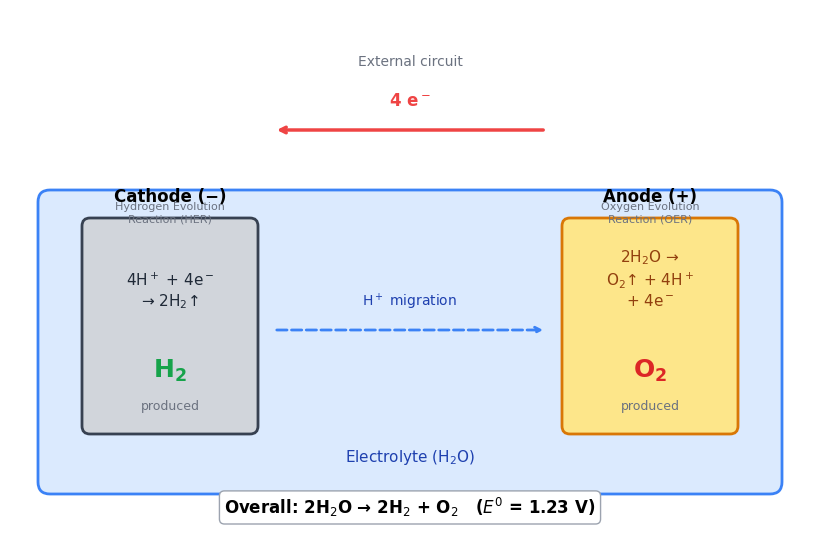

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_xlim(0, 10)
ax.set_ylim(-0.3, 6.2)
ax.set_aspect("equal")
ax.axis("off")

# Electrolyte
ax.add_patch(mpatches.FancyBboxPatch((0.5, 0.3), 9.0, 3.5, boxstyle="round,pad=0.15",
             facecolor="#dbeafe", edgecolor="#3b82f6", linewidth=2))
ax.text(5.0, 0.55, "Electrolyte (H$_2$O)", ha="center", fontsize=11, color="#1e40af")

# Cathode (left) — HER
ax.add_patch(mpatches.FancyBboxPatch((1.0, 1.0), 2.0, 2.5, boxstyle="round,pad=0.1",
             facecolor="#d1d5db", edgecolor="#374151", linewidth=2))
ax.text(2.0, 3.65, "Cathode (−)", ha="center", fontsize=12, fontweight="bold")
ax.text(2.0, 3.35, "Hydrogen Evolution\nReaction (HER)", ha="center", fontsize=8, color="#6b7280")
ax.text(2.0, 2.5, "4H$^+$ + 4e$^-$\n→ 2H$_2$↑", ha="center", fontsize=11, color="#1f2937")
ax.text(2.0, 1.6, r"$\mathbf{H_2}$", ha="center", fontsize=18, color="#16a34a", fontweight="bold")
ax.text(2.0, 1.2, "produced", ha="center", fontsize=9, color="#6b7280")

# Anode (right) — OER
ax.add_patch(mpatches.FancyBboxPatch((7.0, 1.0), 2.0, 2.5, boxstyle="round,pad=0.1",
             facecolor="#fde68a", edgecolor="#d97706", linewidth=2))
ax.text(8.0, 3.65, "Anode (+)", ha="center", fontsize=12, fontweight="bold")
ax.text(8.0, 3.35, "Oxygen Evolution\nReaction (OER)", ha="center", fontsize=8, color="#6b7280")
ax.text(8.0, 2.5, "2H$_2$O →\nO$_2$↑ + 4H$^+$\n+ 4e$^-$", ha="center", fontsize=11, color="#92400e")
ax.text(8.0, 1.6, r"$\mathbf{O_2}$", ha="center", fontsize=18, color="#dc2626", fontweight="bold")
ax.text(8.0, 1.2, "produced", ha="center", fontsize=9, color="#6b7280")

# Electron flow arrow (top)
ax.annotate("", xy=(3.3, 4.7), xytext=(6.7, 4.7),
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#ef4444"))
ax.text(5.0, 5.0, "4 e$^-$", ha="center", fontsize=12, fontweight="bold", color="#ef4444")
ax.text(5.0, 5.5, "External circuit", ha="center", fontsize=10, color="#6b7280")

# Ion flow arrow (middle)
ax.annotate("", xy=(6.7, 2.2), xytext=(3.3, 2.2),
            arrowprops=dict(arrowstyle="->", lw=2, color="#3b82f6", linestyle="dashed"))
ax.text(5.0, 2.5, "H$^+$ migration", ha="center", fontsize=10, color="#1e40af")

# Overall reaction
ax.text(5.0, -0.1, "Overall: 2H$_2$O → 2H$_2$ + O$_2$   ($E^0$ = 1.23 V)",
        ha="center", fontsize=12, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3",
        facecolor="white", edgecolor="#9ca3af"))

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "electrolysis_diagram.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
labels = ["$*$", "OH$^*$", "O$^*$", "OOH$^*$", "$*$ + O$_2$"]

def plot_energy_ladder(ax, steps_vals, color, lw=2.5, alpha=1.0):
    """Draw energy steps as horizontal bars with connecting dashes."""
    for i in range(len(steps_vals)):
        x0 = i * 1.5
        ax.plot([x0, x0 + 1.2], [steps_vals[i], steps_vals[i]], color=color, lw=lw, alpha=alpha)
        if i < len(steps_vals) - 1:
            ax.plot([x0 + 1.2, (i + 1) * 1.5], [steps_vals[i], steps_vals[i + 1]],
                    color=color, lw=1, alpha=alpha * 0.5, linestyle="--")
    for i, lbl in enumerate(labels):
        ax.text(i * 1.5 + 0.6, -0.4, lbl, ha="center", fontsize=10)

# ── Left panel: Non-ideal catalyst ──
ax_l = axes[0]
non_ideal = [0.0, 0.8, 2.8, 3.2, 4.92]
plot_energy_ladder(ax_l, non_ideal, "#2563eb")

deltas = [non_ideal[i + 1] - non_ideal[i] for i in range(4)]
rls_idx = deltas.index(max(deltas))
x_rls = rls_idx * 1.5 + 1.35
y_lo, y_hi = non_ideal[rls_idx], non_ideal[rls_idx + 1]
ax_l.annotate("", xy=(x_rls, y_hi - 0.05), xytext=(x_rls, y_lo + 0.05),
              arrowprops=dict(arrowstyle="<->", lw=2, color="#dc2626"))
rls_label = (r"$\Delta G_{" + str(rls_idx + 1) + r"}$ = "
             + f"{deltas[rls_idx]:.2f} eV" + "\n(rate-limiting)")
ax_l.text(x_rls + 0.15, (y_lo + y_hi) / 2, rls_label,
          fontsize=9, color="#dc2626", va="center",
          bbox=dict(boxstyle="round,pad=0.2", facecolor="#fee2e2", edgecolor="#fca5a5"))

eta = max(deltas) - EV_PER_OER_STEP
ax_l.text(0.5, 4.6, r"$\eta$ = " + f"{eta:.2f} V overpotential",
          fontsize=10, color="#dc2626", fontweight="bold")

ax_l.set_title("Non-Ideal Catalyst", fontsize=13, fontweight="bold")
ax_l.set_ylabel("Adsorption Energy (eV)", fontsize=12)

# ── Right panel: Ideal catalyst ──
ax_r = axes[1]
ideal = [0.0, EV_PER_OER_STEP, 2 * EV_PER_OER_STEP, 3 * EV_PER_OER_STEP, 4 * EV_PER_OER_STEP]
plot_energy_ladder(ax_r, ideal, "#16a34a")

for i in range(4):
    x_mid = i * 1.5 + 1.35
    y_mid = (ideal[i] + ideal[i + 1]) / 2
    ax_r.text(x_mid + 0.1, y_mid, r"$\Delta G$ = " + f"{EV_PER_OER_STEP} eV",
              fontsize=8, color="#16a34a", va="center",
              bbox=dict(boxstyle="round,pad=0.15", facecolor="#dcfce7", edgecolor="#86efac"))

ax_r.text(0.5, 4.6, r"$\eta$ = 0 V (theoretical minimum)", fontsize=10, color="#16a34a", fontweight="bold")
ax_r.set_title("Ideal Catalyst", fontsize=13, fontweight="bold")

for ax in axes:
    ax.set_xlim(-0.3, 7)
    ax.set_ylim(-0.7, 5.5)
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

fig.suptitle("OER Adsorption Energy Diagrams", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "oer_free_energy_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Oxide Catalyst Surfaces

We compare three members of the **rutile-type (P4$_2$/mnm) structure family**, all cleaved along the **(110)** plane. Because the crystal structure prototype is identical across all three oxides, the slab-building recipe is the same for every material — only the lattice parameters and metal species differ. This design ensures a fair comparison of surface chemistry rather than crystallographic artefacts.

The three catalysts span a range of known OER activity:
- **IrO$_2$** — the benchmark acidic OER catalyst and our primary live-relaxation target.
- **RuO$_2$** — a highly active comparator, somewhat less stable than IrO$_2$ under prolonged operation.
- **TiO$_2$** — an abundant, stable oxide that serves as a structural control; it shares the same crystal structure but is catalytically far less active for OER.

The lattice parameters for each material are defined in the **Control Panel** cell above (`RUTILE_PARAMS`). The table below is generated dynamically from those values — if you adjust the parameters, the table updates automatically.

In [9]:
# Display lattice parameters dynamically from RUTILE_PARAMS
roles = {"IrO2": "Benchmark OER catalyst (live)", "RuO2": "Active comparator", "TiO2": "Inactive control"}
param_rows = []
for name, (metal, a, c, u) in RUTILE_PARAMS.items():
    param_rows.append({
        "Material": name,
        "Metal": metal,
        "a (Å)": f"{a:.3f}",
        "c (Å)": f"{c:.3f}",
        "u (oxygen)": f"{u:.4f}",
        "Role": roles.get(name, ""),
    })
display(pd.DataFrame(param_rows))

,Material,Metal,a (Å),c (Å),u (oxygen),Role
0,IrO2,Ir,4.499,3.154,0.3065,Benchmark OER catalyst (live)
1,RuO2,Ru,4.492,3.107,0.3058,Active comparator
2,TiO2,Ti,4.594,2.958,0.3048,Inactive control


In [10]:
# Build rutile bulk crystals
bulks = {}
for name, (metal, a, c, u) in RUTILE_PARAMS.items():
    bulks[name] = build_rutile_bulk(metal, a, c, u)

# Display lattice parameters
rows = []
for name, bulk in bulks.items():
    latt = bulk.lattice
    rows.append(
        {
            "Material": name,
            "a (Å)": f"{latt.a:.3f}",
            "c (Å)": f"{latt.c:.3f}",
            "Atoms/cell": len(bulk),
            "Composition": bulk.composition.reduced_formula,
        }
    )
display(pd.DataFrame(rows))

,Material,a (Å),c (Å),Atoms/cell,Composition
0,IrO2,4.499,3.154,6,IrO2
1,RuO2,4.492,3.107,6,RuO2
2,TiO2,4.594,2.958,6,TiO2


In [11]:
# Build (110) slabs for all three materials
slabs = {}
for name, bulk in bulks.items():
    slabs[name] = build_slab(
        bulk,
        MILLER_INDEX,
        min_slab_size=MIN_SLAB_SIZE,
        min_vacuum_size=MIN_VACUUM,
        supercell=SUPERCELL,
    )
    s = slabs[name]
    print(
        f"{name:6s}  atoms: {len(s):4d}  "
        f"cell: {s.cell.lengths()[0]:.1f} × {s.cell.lengths()[1]:.1f} × {s.cell.lengths()[2]:.1f} Å"
    )

IrO2    atoms:   96  cell: 6.3 × 12.7 × 40.5 Å
RuO2    atoms:   96  cell: 6.2 × 12.7 × 40.4 Å
TiO2    atoms:   96  cell: 5.9 × 13.0 × 41.3 Å


### Visualisation with OVITO

<img src="assets/ovito_logo.png" alt="OVITO" style="height: 50px; float: right; margin-left: 15px;">

Throughout this notebook we use **OVITO** (Open Visualization Tool) for interactive 3-D structure visualisation. OVITO is a scientific visualisation platform for atomistic simulation data, supporting molecular dynamics, Monte Carlo, and DFT output formats [Stukowski, 2010].

OVITO integrates with **NVIDIA hardware** through the **VisRTX renderer** — a hardware-accelerated ray-tracing engine built on the **NVIDIA OptiX** RT-core technology. On CUDA-capable GPUs, VisRTX provides real-time, high-fidelity rendering with global illumination and shadows, making it possible to explore large atomic structures interactively.

The interactive widgets below support mouse rotation, zoom, and pan — try clicking and dragging to explore the 3-D scene.

In [12]:
# Interactive 3-D view of the IrO2(110) slab
for name in ["IrO2"]:
    print(f"{name} (110) slab:")
    display(structure_summary_table(slabs[name]))
    widget = create_interactive_view(slabs[name])
    if widget is not None:
        display(widget)
    elif OVITO_AVAILABLE:
        img = render_structure_ovito(slabs[name], os.path.join(OUTPUT_DIR, f"{name}_slab_110.png"))
        display_inline(img)
    else:
        print("  (OVITO not available)")

IrO2 (110) slab:


,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,Ir32 O64,96,6.308,12.725,40.491,2298.24,5.184


JupyterViewportWidget(layout=Layout(height='400px', width='600px'))

---
## 5. Adsorbate Placement

On the rutile-type (110) surface, two principal adsorption sites are relevant:

- **cus (coordinatively unsaturated site)**: the 5-fold coordinated metal atom exposed at the surface. In the bulk crystal, every metal is octahedrally 6-coordinated; at the (110) surface, one apical oxygen is missing, leaving the metal with a dangling coordination site directly accessible to adsorbates.
- **bridge**: the position between two adjacent cus metal atoms along the [001] direction, near the protruding bridging oxygen rows.

We place four adsorbates — **OH**, **O**, **OOH** (the three OER intermediates used for screening) and **H$_2$O** (a structural probe for dissociative adsorption) — at each site in upright (0°) and tilted (30°) orientations.

**Placement geometry.** The adsorbate's bonding oxygen is positioned at a height defined by `ADSORBATE_HEIGHT` (default 2.0 Å) above the surface site. This height approximates the equilibrium metal–oxygen bond distance for these transition-metal oxides. The **tilted** orientation brings one hydrogen toward a neighbouring bridging oxygen, probing whether surface hydrogen bonding stabilises the adsorption.

In [13]:
# Render the four adsorbate molecules for visual reference
ads_species = ["H2O", "OH", "O", "OOH"]
ads_atoms = {}
for species in ads_species:
    mol = build_adsorbate(species)
    mol.set_cell([6, 6, 6])
    mol.set_pbc([True, True, True])
    mol.center()
    ads_atoms[species] = mol

# Try interactive widgets first; fall back to static PNGs with dark background
widgets_available = create_interactive_view(ads_atoms["O"]) is not None

if widgets_available:
    from ipywidgets import HBox, Layout
    widget_list = []
    for species in ads_species:
        w = create_interactive_view(ads_atoms[species], width="220px", height="220px")
        widget_list.append(w)
    print("OER Adsorbate Intermediates (interactive — drag to rotate)")
    display(HBox(widget_list, layout=Layout(justify_content="center")))
elif OVITO_AVAILABLE:
    # Static fallback with dark background so white H atoms are visible
    fig_ads, axes_ads = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, species in zip(axes_ads, ads_species):
        img_path = render_structure_ovito(
            ads_atoms[species],
            os.path.join(OUTPUT_DIR, f"adsorbate_{species}.png"),
            size=(400, 400),
            background=(0.15, 0.15, 0.15),
        )
        im = plt.imread(img_path)
        ax.imshow(im)
        n_atoms = len(ads_atoms[species])
        ax.set_title(f"{species}$^*$  ({n_atoms} atom{'s' if n_atoms > 1 else ''})", fontsize=12)
        ax.axis("off")
    fig_ads.suptitle("OER Adsorbate Intermediates", fontsize=13, y=1.02)
    fig_ads.tight_layout()
    fig_ads.savefig(os.path.join(OUTPUT_DIR, "adsorbate_intermediates.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    for species in ads_species:
        mol = ads_atoms[species]
        print(f"  {species}: {len(mol)} atoms — {list(mol.get_chemical_symbols())}")

OER Adsorbate Intermediates (interactive — drag to rotate)


In [14]:
# Build all slab+adsorbate configurations
configs = {}  # key: (material, adsorbate, site, tilt_deg) → (atoms, mask)
slab_n_atoms = {}  # key: material → number of slab atoms
site_positions = {}  # key: (material, site_name) → np.ndarray(3,)

for mat_name, slab in slabs.items():
    metal, *_ = RUTILE_PARAMS[mat_name]
    mz = METAL_Z[metal]
    slab_n_atoms[mat_name] = len(slab)

    # Find surface sites
    cus_pos = find_cus_sites(slab, mz)
    bridge_pos = find_bridge_site(slab, mz)
    # Select the most central cus site so the adsorbate is near the slab centre
    central_cus = find_central_site(cus_pos, slab.cell.array)
    sites = {"cus": central_cus, "bridge": bridge_pos}
    for sn, sp in sites.items():
        site_positions[(mat_name, sn)] = sp

    for ads_name in ADSORBATES:
        ads = build_adsorbate(ads_name)
        for site_name in SITES:
            for tilt in ORIENTATIONS[ads_name]:
                key = (mat_name, ads_name, site_name, tilt)
                combined, mask = place_adsorbate(
                    slab,
                    ads,
                    sites[site_name],
                    height=ADSORBATE_HEIGHT,
                    tilt_angle=tilt,
                    frozen_fraction=BOTTOM_FROZEN,
                )
                configs[key] = (combined, mask)

print(f"Total configurations: {len(configs)}")
print(f"  Per material: {len(configs) // len(RUTILE_PARAMS)}")

# Summary table
summary_rows = []
for (mat, ads, site, tilt), (atoms, _) in configs.items():
    summary_rows.append(
        {
            "Material": mat,
            "Adsorbate": ads,
            "Site": site,
            "Tilt (°)": tilt,
            "Atoms": len(atoms),
        }
    )
summary_df = pd.DataFrame(summary_rows)
print("\nConfigurations per material:")
display(summary_df.groupby(["Material", "Adsorbate"]).size().unstack(fill_value=0))

Total configurations: 42
  Per material: 14

Configurations per material:


Adsorbate,H2O,O,OH,OOH
Material,,,,
IrO2,4,2,4,4
RuO2,4,2,4,4
TiO2,4,2,4,4


In [15]:
# Show a few representative initial configurations
examples = [
    ("IrO2", "OH", "cus", 0.0),
    ("IrO2", "H2O", "cus", 30.0),
    ("IrO2", "OOH", "cus", 0.0),
]
for key in examples:
    if key in configs:
        atoms, _ = configs[key]
        label = f"{key[0]}+{key[1]} ({key[2]}, tilt={int(key[3])}°)"
        print(label)
        widget = create_interactive_view(atoms)
        if widget is not None:
            display(widget)
        elif OVITO_AVAILABLE:
            tag = f"{key[0]}_{key[1]}_{key[2]}_tilt{int(key[3])}"
            img = render_structure_ovito(atoms, os.path.join(OUTPUT_DIR, f"init_{tag}.png"))
            display_inline(img)
        else:
            print(f"  {len(atoms)} atoms")

IrO2+OH (cus, tilt=0°)


JupyterViewportWidget(layout=Layout(height='400px', width='600px'))

IrO2+H2O (cus, tilt=30°)


JupyterViewportWidget(layout=Layout(height='400px', width='600px'))

IrO2+OOH (cus, tilt=0°)


JupyterViewportWidget(layout=Layout(height='400px', width='600px'))

---
## 6. Clean Slab and Gas-Phase Reference Relaxation

To compute adsorption energies we need:

$$E_{\text{ads}} = E(\text{slab+adsorbate}) - E(\text{clean slab}) - E(\text{gas-phase adsorbate})$$

We first relax the three clean slabs and the four isolated gas-phase molecules (each placed in a large vacuum box with PBC).

In [ ]:
import aiohttp
import asyncio

# --- Async clean slab + gas-phase reference relaxation ---
clean_energies = {}
gas_energies = {}

async def _run_references():
    """Relax clean slabs and gas-phase references concurrently."""
    connector = aiohttp.TCPConnector(limit=5)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        # Clean slabs
        for mat_name, slab in slabs.items():
            mask = make_active_mask(slab, BOTTOM_FROZEN)
            ad = ase_to_atomic_data(slab, _id=f"{mat_name.lower()}_clean_slab", active_mask=mask)
            label = f"{mat_name.lower()}_clean_slab"
            tasks.append(("clean", mat_name, async_run_bgr_or_load_cache(
                [ad], BGR_SERVER, session, CACHE_DIR, label, bgr_live, timeout=300
            )))
        # Gas-phase references
        for species in ADSORBATES:
            mol = build_adsorbate(species)
            mol.set_cell([GAS_BOX_SIZE] * 3)
            mol.set_pbc([True, True, True])
            mol.center()
            ad = ase_to_atomic_data(mol, _id=f"gas_{species.lower()}")
            label = f"gas_{species.lower()}"
            tasks.append(("gas", species, async_run_bgr_or_load_cache(
                [ad], BGR_SERVER, session, CACHE_DIR, label, bgr_live, timeout=120
            )))
        results = await asyncio.gather(*[coro for _, _, coro in tasks])
        for (tag, name, _), result in zip(tasks, results):
            if tag == "clean":
                clean_energies[name] = result.atoms[0].energy
            else:
                gas_energies[name] = result.atoms[0].energy

await _run_references()

print("Clean slab energies:")
for name, e in clean_energies.items():
    print(f"  {name}: E = {e:.4f} eV")
print("\nGas-phase reference energies:")
for name, e in gas_energies.items():
    print(f"  {name:4s}: E = {e:.4f} eV")

---
## 7. Batched Geometry Relaxation

The ALCHEMI BGR NIM uses **MACE-MP-0** as the machine-learning interatomic potential — a foundation model covering 89 elements, trained on 1.6 million Materials Project bulk-crystal structures.  For geometry optimisation it employs an in-house **FIRE**-style optimiser that efficiently drives structures toward local energy minima.

### ALCHEMI performance features

The BGR NIM is designed for high-throughput screening, not just single-structure relaxation:

1. **Batching** — multiple structures are submitted in a single API call, amortising overhead and enabling the GPU scheduler to fill all available compute.
2. **GPU-parallelised neighbour-list construction** — the neighbour list (the most expensive bookkeeping step for each force evaluation) is built entirely on GPU, avoiding a CPU bottleneck.
3. **GPU-accelerated DFT-D3 dispersion corrections** — semi-empirical dispersion (DFT-D3) corrections are computed on GPU in parallel with the MLIP forces, improving accuracy for surface–adsorbate van-der-Waals interactions at negligible extra cost.

Together these features allow batched relaxation of tens to hundreds of candidate structures in wall times that make interactive screening practical.

In [ ]:
relaxation_results = {}  # key -> OptimizationResult
t0 = time.time()

async def _run_all_slab_bgr():
    """Relax ALL slab+adsorbate structures concurrently via async BGR."""
    connector = aiohttp.TCPConnector(limit=5)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        for key in configs:
            atoms, mask = configs[key]
            mat, ads, site, tilt = key
            label = f"{mat.lower()}_{ads.lower()}_{site}_tilt{int(tilt)}"
            ad = ase_to_atomic_data(atoms, _id=label, active_mask=mask)
            tasks.append(
                (
                    key,
                    async_run_bgr_or_load_cache(
                        [ad], BGR_SERVER, session, CACHE_DIR, label, bgr_live, timeout=300
                    ),
                )
            )
        keys = [k for k, _ in tasks]
        results = await asyncio.gather(*[coro for _, coro in tasks])
        for key, result in zip(keys, results):
            relaxation_results[key] = result.atoms[0]

await _run_all_slab_bgr()
elapsed = time.time() - t0

print(f"Relaxed {len(relaxation_results)} structures in {elapsed:.1f} s (async)")
for key, res in relaxation_results.items():
    mat, ads, site, tilt = key
    print(f"  {mat}+{ads:4s} {site:6s} tilt={int(tilt):2d}deg  "
          f"E={res.energy:10.4f} eV  conv={res.converged}  "
          f"steps={res.num_optimization_steps}")

In [ ]:
conv_rows = []
for key, res in relaxation_results.items():
    mat, ads, site, tilt = key
    forces = np.array(res.forces).reshape(-1, 3)
    max_f = float(np.max(np.linalg.norm(forces, axis=1)))
    conv_rows.append({
        "Material": mat, "Adsorbate": ads, "Site": site,
        "Tilt (°)": int(tilt), "Converged": res.converged,
        "Steps": res.num_optimization_steps, "Max force (eV/Å)": f"{max_f:.4f}",
        "Energy (eV)": f"{res.energy:.4f}",
    })
conv_df = pd.DataFrame(conv_rows)
display(conv_df)
n_conv = conv_df["Converged"].sum()
print(f"\n{n_conv}/{len(conv_df)} structures converged.")

---
## 8. Relaxation Quality Control

Relaxation output is only useful after basic quality checks.  For each structure we evaluate:

| Metric | What it tells us |
|--------|-----------------|
| **Max force** | Whether the optimiser truly converged |
| **Adsorbate height** | Whether the adsorbate is still bound to the surface |
| **Nearest metal distance** | Closest metal–adsorbate contact |
| **Site drift** | Whether the adsorbate migrated laterally |
| **Dissociation check** | Whether molecular adsorbates broke apart |

Each structure is assigned a status flag: `converged`, `moved_to_new_site`, `dissociated`, `desorbed`, or `needs_review`.

In [ ]:
classification_rows = []
for key, res in relaxation_results.items():
    mat, ads, site, tilt = key
    initial_atoms, _ = configs[key]
    metal = RUTILE_PARAMS[mat][0]
    mz = METAL_Z[metal]
    site_init = site_positions[(mat, site)]

    info = classify_relaxation(
        initial=initial_atoms,
        relaxed_result=res,
        slab_n_atoms=slab_n_atoms[mat],
        site_initial=site_init,
        metal_z=mz,
    )
    info["material"] = mat
    info["adsorbate"] = ads
    info["site"] = site
    info["tilt"] = int(tilt)
    classification_rows.append(info)

class_df = pd.DataFrame(classification_rows)
display(class_df[["material", "adsorbate", "site", "tilt", "status",
                   "converged", "max_force", "adsorbate_height",
                   "nearest_metal_dist", "site_drift", "energy"]])

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
status_counts = class_df.groupby(["material", "status"]).size().unstack(fill_value=0)

colors = {
    "converged": "#22c55e",
    "moved_to_new_site": "#f59e0b",
    "dissociated": "#ef4444",
    "desorbed": "#6366f1",
    "needs_review": "#9ca3af",
}
ordered_statuses = [s for s in colors if s in status_counts.columns]
status_counts[ordered_statuses].plot.bar(
    ax=ax, color=[colors[s] for s in ordered_statuses], edgecolor="white", width=0.7
)
ax.set_ylabel("Count")
ax.set_title("Relaxation Outcome by Material")
ax.set_xlabel("")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "relaxation_status.png"), dpi=150)
plt.show()

In [ ]:
# Before/after comparison for a converged IrO2+OH structure
example_key = ("IrO2", "OH", "cus", 0.0)
if example_key in relaxation_results and OVITO_AVAILABLE:
    init_atoms, _ = configs[example_key]
    res = relaxation_results[example_key]
    relax_atoms = atomic_data_to_ase(res)

    img_before = render_structure_ovito(
        init_atoms, os.path.join(OUTPUT_DIR, "iro2_oh_cus_before.png")
    )
    img_after = render_structure_ovito(
        relax_atoms, os.path.join(OUTPUT_DIR, "iro2_oh_cus_after.png")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax_i, (img_path, title) in zip(
        axes, [(img_before, "Before relaxation"), (img_after, "After relaxation")]
    ):
        im = plt.imread(img_path)
        ax_i.imshow(im)
        ax_i.set_title(title, fontsize=13)
        ax_i.axis("off")
    fig.suptitle("IrO$_2$(110) + OH$^*$ (cus, upright)", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(
        os.path.join(OUTPUT_DIR, "iro2_oh_before_after.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Skipping before/after render (OVITO unavailable or key missing).")

### Surface displacement upon adsorption

A good OER catalyst ideally shows **minimal rearrangement of its surface atoms** when an intermediate binds.  Large atomic displacements suggest the surface may reconstruct under operating conditions, complicating practical use and potentially degrading long-term stability.

Below we colour-map the displacement of each slab atom from its initial position (blue = small, red = large).

In [ ]:
# Compute surface displacement for converged IrO2 structures
disp_data = {}
for key, res in relaxation_results.items():
    mat, ads, site, tilt = key
    row = next(
        r
        for r in classification_rows
        if r["material"] == mat
        and r["adsorbate"] == ads
        and r["site"] == site
        and r["tilt"] == int(tilt)
    )
    if row["status"] not in ("converged", "moved_to_new_site"):
        continue
    init_atoms, _ = configs[key]
    relax_atoms = atomic_data_to_ase(res)
    n_slab = slab_n_atoms[mat]
    disp = compute_surface_displacement(init_atoms, relax_atoms, n_slab)
    disp_data[key] = disp

# Plot displacement distribution for each material
fig, axes = plt.subplots(1, len(RUTILE_PARAMS), figsize=(14, 4), sharey=True)
mat_colors = {"IrO2": "#2563eb", "RuO2": "#16a34a", "TiO2": "#dc2626"}
for ax, mat_name in zip(axes, RUTILE_PARAMS):
    mat_disps = {k: v for k, v in disp_data.items() if k[0] == mat_name}
    if mat_disps:
        all_d = np.concatenate(list(mat_disps.values()))
        ax.hist(
            all_d, bins=30, color=mat_colors[mat_name], alpha=0.8, edgecolor="white"
        )
    ax.set_title(mat_name)
    ax.set_xlabel("Displacement (Å)")
axes[0].set_ylabel("Count")
fig.suptitle("Surface Atom Displacement After Adsorbate Relaxation", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "surface_displacement.png"), dpi=150)
plt.show()

In [ ]:
# Look for a dissociated or migrated structure to highlight
surprising = class_df[class_df["status"].isin(["dissociated", "moved_to_new_site"])]
if len(surprising) > 0 and OVITO_AVAILABLE:
    row = surprising.iloc[0]
    key = (row["material"], row["adsorbate"], row["site"], float(row["tilt"]))
    if key in relaxation_results:
        res = relaxation_results[key]
        relax_atoms = atomic_data_to_ase(res)
        label = f"{row['material']}+{row['adsorbate']}_{row['site']}_tilt{row['tilt']}"
        img = render_structure_ovito(
            relax_atoms, os.path.join(OUTPUT_DIR, f"surprising_{label}.png")
        )
        print(f"Surprising case: {label} — status = {row['status']}")
        display_inline(img)
elif len(surprising) > 0:
    row = surprising.iloc[0]
    print(
        f"Surprising case (no OVITO): {row['material']}+{row['adsorbate']} "
        f"({row['site']}) → {row['status']}"
    )
    print(
        f"  Site drift: {row['site_drift']:.2f} Å, Height: {row['adsorbate_height']:.2f} Å"
    )
else:
    print("All structures converged on their initial sites (no surprising cases).")

---
## 9. Adsorption Energies

With clean slab and gas-phase reference energies in hand, we compute the adsorption energy for every converged structure:

$$E_{\text{ads}} = E(\text{slab+adsorbate}) - E(\text{clean slab}) - E(\text{gas-phase molecule})$$

A **negative** value indicates exothermic (favourable) binding.  We then rank configurations within each material–adsorbate block by $E_{\text{ads}}$.

In [ ]:
# Compute adsorption energies for all converged/moved structures
e_ads_rows = []
for row in classification_rows:
    if row["status"] in ("desorbed", "needs_review"):
        continue
    mat = row["material"]
    ads = row["adsorbate"]
    e_ads = compute_adsorption_energy(row["energy"], clean_energies[mat], gas_energies[ads])
    e_ads_rows.append({
        "Material": mat, "Adsorbate": ads, "Site": row["site"],
        "Tilt (°)": row["tilt"], "E_ads (eV)": round(e_ads, 4),
        "Status": row["status"],
    })

e_ads_df = pd.DataFrame(e_ads_rows)
e_ads_df = e_ads_df.sort_values(["Material", "Adsorbate", "E_ads (eV)"])
display(e_ads_df)

In [ ]:
# Heatmap: lowest adsorption energy per (Material, Adsorbate)
pivot = e_ads_df.groupby(["Material", "Adsorbate"])["E_ads (eV)"].min().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color="white" if abs(val) > 2 else "black",
            )

ax.set_title("Lowest Adsorption Energy (eV) by Material × Adsorbate", fontsize=12)
fig.colorbar(im, ax=ax, label="$E_{\mathrm{ads}}$ (eV)", shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "eads_heatmap.png"), dpi=150)
plt.show()

In [ ]:
# Nearest metal-adsorbate distances for converged structures
bond_rows = []
for row in classification_rows:
    if row["status"] == "desorbed":
        continue
    bond_rows.append(
        {
            "Material": row["material"],
            "Adsorbate": row["adsorbate"],
            "Site": row["site"],
            "Tilt": row["tilt"],
            "Metal-O dist (Å)": f"{row['nearest_metal_dist']:.3f}",
            "Height (Å)": f"{row['adsorbate_height']:.3f}",
            "Status": row["status"],
        }
    )
display(pd.DataFrame(bond_rows))

---
## 10. Screening Results & Material Ranking

### 3-D Adsorption-Energy Scatter

For each material, we take the **lowest** adsorption energy across all sites and orientations for each OER intermediate (OH$^*$, O$^*$, OOH$^*$).  The three energies define a point in 3-D space.  The **ideal OER catalyst** sits at **(1.23, 2.46, 3.69) eV** — the cumulative free energies for equal-step thermodynamics.  The **Euclidean distance** from each material's point to this target is a simple screening metric.

In [ ]:
# Build best E_ads per (material, OER intermediate)
oer_intermediates = ["OH", "O", "OOH"]
target = np.array([1 * EV_PER_OER_STEP, 2 * EV_PER_OER_STEP, 3 * EV_PER_OER_STEP])

mat_points = {}
for mat_name in RUTILE_PARAMS:
    point = []
    for ads in oer_intermediates:
        subset = e_ads_df[
            (e_ads_df["Material"] == mat_name) & (e_ads_df["Adsorbate"] == ads)
        ]
        if len(subset) > 0:
            point.append(subset["E_ads (eV)"].min())
        else:
            point.append(np.nan)
    mat_points[mat_name] = np.array(point)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

mat_colors = {"IrO2": "#2563eb", "RuO2": "#16a34a", "TiO2": "#dc2626"}
mat_markers = {"IrO2": "o", "RuO2": "s", "TiO2": "D"}

# Plot material points
for mat_name, pt in mat_points.items():
    if np.any(np.isnan(pt)):
        continue
    dist = np.linalg.norm(pt - target)
    ax.scatter(
        *pt,
        c=mat_colors[mat_name],
        marker=mat_markers[mat_name],
        s=150,
        edgecolors="k",
        linewidth=0.8,
        zorder=5,
        label=f"{mat_name} (d={dist:.2f})",
    )
    # Dashed line to target
    ax.plot(
        [pt[0], target[0]],
        [pt[1], target[1]],
        [pt[2], target[2]],
        "--",
        color=mat_colors[mat_name],
        alpha=0.5,
        lw=1,
    )

# Plot target point
ax.scatter(
    *target,
    c="gold",
    marker="*",
    s=400,
    edgecolors="k",
    linewidth=1,
    zorder=10,
    label="Ideal OER catalyst",
)

ax.set_xlabel("$E_{\mathrm{ads}}$(OH$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_ylabel("$E_{\mathrm{ads}}$(O$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_zlabel("$E_{\mathrm{ads}}$(OOH$^*$) (eV)", fontsize=10, labelpad=8)
ax.set_title(
    "OER Catalyst Screening — 3-D Adsorption Energy Space", fontsize=12, pad=15
)
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(
    os.path.join(OUTPUT_DIR, "oer_3d_scatter.png"), dpi=150, bbox_inches="tight"
)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ideal catalyst
ideal_steps = [0.0, 1.23, 2.46, 3.69, 4.92]
labels = ["$*$", "OH$^*$", "O$^*$", "OOH$^*$", "$*$ + O$_2$"]


def plot_energy_ladder(ax, steps_vals, color, label, lw=2, alpha=1.0):
    for i in range(len(steps_vals)):
        x0 = i * 1.5
        ax.plot(
            [x0, x0 + 1.2],
            [steps_vals[i], steps_vals[i]],
            color=color,
            lw=lw,
            alpha=alpha,
        )
        if i < len(steps_vals) - 1:
            ax.plot(
                [x0 + 1.2, (i + 1) * 1.5],
                [steps_vals[i], steps_vals[i + 1]],
                color=color,
                lw=1,
                alpha=alpha * 0.5,
                linestyle="--",
            )
    ax.plot([], [], color=color, lw=lw, label=label)


plot_energy_ladder(ax, ideal_steps, "black", "Ideal catalyst", lw=2.5)

# Material ladders from computed adsorption energies
for mat_name in RUTILE_PARAMS:
    mat_steps = [0.0]
    valid = True
    for ads in oer_intermediates:
        subset = e_ads_df[
            (e_ads_df["Material"] == mat_name) & (e_ads_df["Adsorbate"] == ads)
        ]
        if len(subset) > 0:
            mat_steps.append(subset["E_ads (eV)"].min())
        else:
            valid = False
            break
    if valid:
        # Final step: O2 release = 4.92 eV total
        mat_steps.append(4.92)
        plot_energy_ladder(
            ax, mat_steps, mat_colors[mat_name], mat_name, lw=2, alpha=0.8
        )

# Labels
for i, lbl in enumerate(labels):
    ax.text(i * 1.5 + 0.6, -0.5, lbl, ha="center", fontsize=10)

ax.set_ylabel("Free energy (eV)", fontsize=12)
ax.set_title("OER Free Energy Diagram — Material Comparison", fontsize=13)
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(-0.3, 7)
ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "oer_material_comparison.png"), dpi=150)
plt.show()

In [ ]:
# Rank materials by Euclidean distance to ideal OER target
ranking_rows = []
for mat_name, pt in mat_points.items():
    if np.any(np.isnan(pt)):
        ranking_rows.append(
            {
                "Material": mat_name,
                "Distance to ideal": np.nan,
                "E_ads(OH*)": np.nan,
                "E_ads(O*)": np.nan,
                "E_ads(OOH*)": np.nan,
            }
        )
        continue
    dist = float(np.linalg.norm(pt - target))
    ranking_rows.append(
        {
            "Material": mat_name,
            "E_ads(OH*) (eV)": round(pt[0], 3),
            "E_ads(O*) (eV)": round(pt[1], 3),
            "E_ads(OOH*) (eV)": round(pt[2], 3),
            "Distance to ideal": round(dist, 3),
        }
    )

ranking_df = pd.DataFrame(ranking_rows).sort_values("Distance to ideal")
display(ranking_df)

best = ranking_df.iloc[0]["Material"]
print(f"\nClosest to ideal OER catalyst: {best}")

---
## Discussion

### Key observations

- **Which initial guesses relaxed to the same final motif?**  Multiple starting configurations (different sites, orientations) may converge to identical relaxed geometries — this is a sign that the potential energy surface has a clear minimum for that adsorbate on that surface.

- **Which surface holds OH$^*$ most stably?**  The adsorption energy heatmap shows which material binds each intermediate most strongly.  Strong OH$^*$ binding is a prerequisite for OER activity, but binding that is *too* strong leads to poisoning.

- **Does H$_2$O$^*$ stay molecular or dissociate?**  On stoichiometric IrO$_2$(110), strong dissociative water adsorption is well-documented in the literature.  Observing this in the relaxation is a useful validation of the MLIP model's qualitative accuracy.

- **How does OOH$^*$ behave?**  The peroxo intermediate is often the least stable of the three OER intermediates.  Its relaxed geometry (intact O–O bond, orientation relative to the surface) contains information about the feasibility of the O$_2$-release step.

- **Surface displacement.**  Materials that showed minimal surface rearrangement upon adsorbate binding are more likely to be practically stable catalysts.  Large displacements suggest the surface may reconstruct under OER conditions.

### Caveats

This notebook performs **vacuum-slab structural screening** — a useful first funnel, but not a definitive mechanistic study.  Important physics that is missing:

- **Explicit solvent and electrochemical potential**: water molecules at the electrode–electrolyte interface stabilise intermediates through hydrogen bonding and dielectric screening.
- **Zero-point energy (ZPE) and entropy corrections**: converting electronic adsorption energies to free energies requires vibrational contributions.
- **Coverage effects**: at operating potentials, the surface may be partially covered by multiple intermediates simultaneously.
- **MLIP accuracy**: MACE-MP-0 is a broadly capable foundation model, but its accuracy on surface-adsorption energetics for specific oxides should be validated against DFT references.

The strongest message for tutorial attendees: **batched MLIP relaxation is excellent for rapid structural screening and hypothesis pruning, but final catalyst claims still require richer physics and downstream validation.**

---
## 11. Extensions & Scaling

| Direction | What it adds |
|-----------|-------------|
| **Explicit solvent** | Solvation stabilises OH$^*$ and OOH$^*$ differently; improves free-energy accuracy |
| **ZPE & entropy corrections** | Converts $E_{\text{ads}}$ to $\Delta G$; essential for overpotential estimates |
| **Alloy surfaces** | Ir$_x$Ru$_{1-x}$O$_2$ and doped TiO$_2$ explore cost–activity trade-offs |
| **Higher-coverage screening** | Co-adsorbed intermediates (e.g. OH$^*$ + O$^*$) at realistic potentials |
| **Agentic AI loop** | An LLM agent picks the next surface/adsorbate configuration based on prior results, closing the active-learning loop |
| **DFT validation** | Spot-check the most promising MLIP results with hybrid-functional DFT |

## Summary

1. **Batching enables many structural hypotheses.** We screened 30+ slab-adsorbate configurations across three rutile oxides in a single interactive session — a throughput that would be impractical with serial DFT calculations.

2. **Quality control is essential.** Not every relaxed structure is scientifically useful.  Classification into converged / migrated / dissociated / desorbed categories separates reliable data from noise.

3. **Vacuum relaxation is the first funnel, not the last.** The adsorption-energy ranking and 3-D scatter plot provide a rapid first screen, but final catalyst claims require explicit solvent, free-energy corrections, and experimental validation.

### Discussion Prompts

1. Did batching help primarily because we had **many materials**, or because we had **many structural hypotheses** per material?
2. Is the lowest-energy relaxed structure automatically the best catalyst?
3. What extra physics is missing from a vacuum slab relaxation, and which missing piece matters most for OER?
4. When should you escalate from MLIP screening to DFT, explicit solvent, or experiment?
5. How might an **agentic AI** system decide which configuration to try next?

## References

1. Batatia, I. *et al.* "MACE: Higher Order Equivariant Message Passing Neural Networks for Fast and Accurate Force Fields." *NeurIPS* (2022). — MACE-MP-0 foundation model covering 89 elements trained on 1.6M Materials Project structures.
2. Rossmeisl, J., Qu, Z.-W., Zhu, H., Kroes, G.-J. & Norskov, J. K. "Electrolysis of water on oxide surfaces." *J. Electroanal. Chem.* **607**, 83–89 (2007). — OER thermodynamic framework with four PCET steps and 1.23 eV ideal step energy.
3. Ping, Y., Nielsen, R. J. & Goddard, W. A. "The Reaction Mechanism with Free Energy Barriers at Constant Potentials for the Oxygen Evolution Reaction at the IrO$_2$ (110) Surface." *J. Am. Chem. Soc.* **139**, 149–155 (2017). — IrO$_2$(110) as OER reference; strong dissociative H$_2$O adsorption.
4. Dickens, C. F., Kirk, C. & Norskov, J. K. "Insights into the Electrochemical Oxygen Evolution Reaction with ab Initio Calculations and Microkinetic Modeling: Beyond the Limiting Potential Volcano." *J. Phys. Chem. C* **123**, 18960–18977 (2019). — Comparative OER study on TiO$_2$, RuO$_2$, and IrO$_2$ (110) surfaces.
5. Stukowski, A. "Visualization and analysis of atomistic simulation data with OVITO — the Open Visualization Tool." *Model. Simul. Mater. Sci. Eng.* **18**, 015012 (2010).
6. U.S. Geological Survey. "2022 Final List of Critical Minerals." *Federal Register* **87**, 10381 (2022). — Iridium among 60 critical minerals.
7. ENEOS Holdings, Matlantis, and NVIDIA. Collaboration on GPU-accelerated atomistic simulation for catalyst discovery.